# MODELOS

In [13]:
import plotly.express as px
import pandas as pd
import nbformat
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, ConfusionMatrixDisplay
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix
from scipy.stats import shapiro, kstest, chi2, norm, zscore, randint
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import export_graphviz
import graphviz

In [14]:
df_arrest = pd.read_csv("data/df_arrest.csv")

## GET DUMMIES

Creamos dummies para categoricas object

In [15]:
# Seleccionar las columnas categóricas con letras (de tipo 'object')
categorical_cols = df_arrest.select_dtypes(include=['str']).columns

# Crear valores dummy para las variables categóricas seleccionadas
df_arrest_dummies = pd.get_dummies(df_arrest, columns=categorical_cols)
display(df_arrest_dummies.head(5))

,month,year,meters,age,arstmade_cod,violencia,recstat_1,recstat_A,inout_I,inout_O,...,beat_5,beat_6,beat_61,beat_62,beat_7,beat_8,beat_9,beat_U,dettypcm_,dettypcm_CM
0,4,2009,1.7526,24,0,0,False,True,False,True,...,False,False,False,False,True,False,False,False,False,True
1,10,2009,1.6510,15,0,0,False,True,False,True,...,False,False,False,False,False,False,False,True,False,True
2,10,2009,1.9050,21,0,0,True,False,False,True,...,False,False,False,False,False,False,False,True,False,True
3,1,2009,1.6510,22,0,0,False,True,False,True,...,False,False,False,False,False,False,False,False,False,True
4,12,2009,1.6764,18,0,0,False,True,False,True,...,False,False,False,False,False,False,False,True,False,True


## SET DE DATOS PARA ENTRENAMIENTO Y DE PRUEBA

Creamos los dos set de datos: 2009 será entrenamiento y 2010 será prueba.

In [16]:
#creamos los 2 set de datos
# Filtrar las filas donde la variable 'year' es igual a 2009
df_dummies_9 = df_arrest_dummies[df_arrest_dummies['year'] == 2009]

# Filtrar las filas donde la variable 'year' es igual a 2010
df_dummies_10 =df_arrest_dummies[df_arrest_dummies['year'] == 2010]

display(df_dummies_9.tail(5))
display("*******")
display(df_dummies_10.tail(5))

,month,year,meters,age,arstmade_cod,violencia,recstat_1,recstat_A,inout_I,inout_O,...,beat_5,beat_6,beat_61,beat_62,beat_7,beat_8,beat_9,beat_U,dettypcm_,dettypcm_CM
5807,3,2009,1.7272,17,1,0,False,True,False,True,...,False,False,False,False,False,False,False,True,False,True
5808,9,2009,1.8034,19,0,1,False,True,False,True,...,False,False,False,False,False,False,False,False,False,True
5809,6,2009,1.7018,30,0,0,True,False,False,True,...,False,False,False,False,False,False,False,True,False,True
5810,3,2009,1.7272,31,1,1,True,False,False,True,...,False,False,False,False,False,False,False,False,False,True
5811,5,2009,1.8288,31,0,0,True,False,False,True,...,False,False,False,False,False,False,False,True,False,True


'*******'

,month,year,meters,age,arstmade_cod,violencia,recstat_1,recstat_A,inout_I,inout_O,...,beat_5,beat_6,beat_61,beat_62,beat_7,beat_8,beat_9,beat_U,dettypcm_,dettypcm_CM
11820,9,2010,1.7780,20,0,1,True,False,False,True,...,False,False,False,False,False,False,False,True,False,True
11821,7,2010,1.7018,23,0,0,False,True,False,True,...,False,False,False,False,False,False,False,True,False,True
11822,4,2010,1.8288,1,0,0,False,True,False,True,...,False,False,False,False,False,False,False,True,False,True
11823,11,2010,1.8034,19,0,1,True,False,False,True,...,False,False,False,False,False,False,False,True,False,True
11824,1,2010,1.8542,36,0,0,True,False,True,False,...,False,False,False,False,False,False,False,False,False,True


## PROBANDO MODELO GRADIENT BOOSTING

In [17]:
#Preparar los datos
X_train = df_dummies_9.drop('arstmade_cod', axis=1)
y_train = df_dummies_9['arstmade_cod']
X_test = df_dummies_10.drop('arstmade_cod', axis=1)
y_test = df_dummies_10['arstmade_cod']

# Escalar las variables independientes
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Crear el modelo de Gradient Boosting
gb_clf = GradientBoostingClassifier(random_state=42)

# Entrenar el modelo con el conjunto de entrenamiento
gb_clf.fit(X_train_scaled, y_train)

# Predecir las etiquetas para el conjunto de testeo
y_pred = gb_clf.predict(X_test_scaled)

# Predicciones

y_pred = gb_clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("La precision de testeo del modelo es:", accuracy)

La precision de testeo del modelo es: 0.8923998004323965


c:\Users\Usuario\al-ke-la-prediccion_arrestos\.venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but GradientBoostingClassifier was fitted without feature names
  warnings.warn(


Usaremos RandomizedSearchCV para encontrar los mejores hiperparámetros en el modelo de Gradient Boosting.

Mejores hiperparámetros: {'learning_rate': 0.05, 'max_depth': 5, 'min_samples_split': 8, 'n_estimators': 124}
Matriz de confusión:
[[5560   53]
 [ 169  231]]
Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      5613
           1       0.81      0.58      0.68       400

    accuracy                           0.96      6013
   macro avg       0.89      0.78      0.83      6013
weighted avg       0.96      0.96      0.96      6013



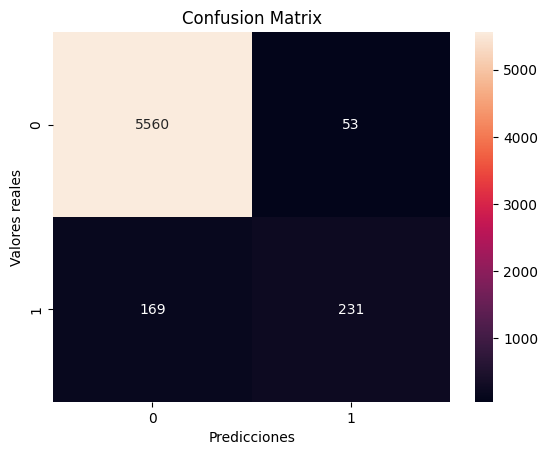

In [18]:
# Definir el modelo de Gradient Boosting
gb_clf = GradientBoostingClassifier(random_state=42)

# Definir el espacio de búsqueda de hiperparámetros
param_dist = {
    'n_estimators': randint(50, 200),  # Número de árboles en el modelo
    'max_depth': randint(3, 10),       # Profundidad máxima de cada árbol
    'min_samples_split': randint(2, 10), # Número mínimo de muestras para dividir un nodo
    'learning_rate': [0.01, 0.05, 0.1, 0.2] # Tasa de aprendizaje
}

# Crear el objeto RandomizedSearchCV
random_search = RandomizedSearchCV(estimator=gb_clf, param_distributions=param_dist,
                                   n_iter=10, cv=2, scoring='accuracy', random_state=42)

# Realizar la búsqueda aleatoria de hiperparámetros
random_search.fit(X_train_scaled, y_train)

# Mostrar los mejores hiperparámetros encontrados
print(f'Mejores hiperparámetros: {random_search.best_params_}')

# Evaluar el mejor modelo en el conjunto de testeo
best_gb_clf = random_search.best_estimator_
y_pred = best_gb_clf.predict(X_test_scaled)

# Obtener la matriz de confusión
conf_matrix = confusion_matrix(y_test, y_pred)
print('Matriz de confusión:')
print(conf_matrix)

# Obtener el reporte de clasificación
class_report = classification_report(y_test, y_pred)
print('Reporte de clasificación:')
print(class_report)

# Graficar la matriz de confusión
sns.heatmap(conf_matrix, annot=True, fmt='g')
plt.xlabel('Predicciones')
plt.ylabel('Valores reales')
plt.title('Confusion Matrix')
plt.show()

## Conclusión: 

En este modelo se obtienen buenos niveles de precision. Usando un 5% de los datos se obtiene un accuracy de 96% para testeo.
El modelo es mejor clasificando los casos de No Arresto en el 96% de las veces.
Tiene una tasa Recall(sensibilidad) de 99% lo que muestra buena capacidad del clasificador de encontrar las muestras positivas.
Tiene una tasa Recall(especificidad) de 58%  lo que muestra que el modelo tiene probabilidades de clasificar erróneamente un caso negativo como positivo (Falso Positivo). Es decir predice "arrestado" a individuos que en los datos no lo están.

## PROBANDO MODELO RANDOM FOREST

In [19]:
#Paso 1: Preparar los datos
X_train = df_dummies_9.drop('arstmade_cod', axis=1)
y_train = df_dummies_9['arstmade_cod']
X_test = df_dummies_10.drop('arstmade_cod', axis=1)
y_test = df_dummies_10['arstmade_cod']

rf = RandomForestClassifier(random_state=0)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [20]:
# Predicciones

y_pred = rf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("La precision de testeo del modelo es:", accuracy)

La precision de testeo del modelo es: 0.9640778313653751


## Conclusión: 

El Accuracy de testeo usando Random Forest es tan preciso como el modelo de Gradient Boosting.
Ajustaremos los hiperparámetros en Random Forest para revisar si el accuracy aumenta.

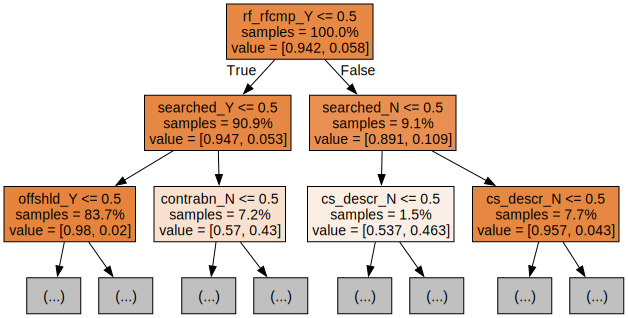

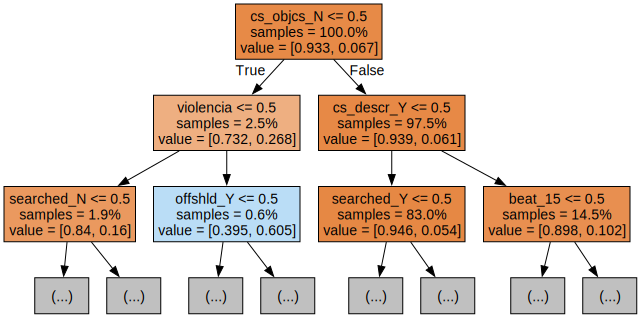

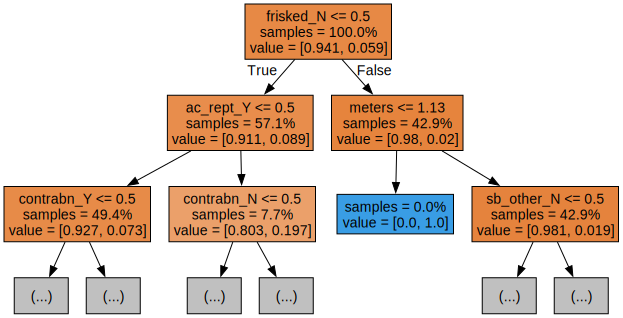

In [21]:
# Visualizar los primeros 3 árboles
for i in range(3):
    tree = rf.estimators_[i]
    dot_data = export_graphviz(tree,
                               feature_names=X_train.columns,
                               filled=True,
                               max_depth=2,
                               impurity=False,
                               proportion=True)
    graph = graphviz.Source(dot_data)
    display(graph)

Usar RandomizedSearchCV para encontrar los mejores hiperparámetros en el modelo de Randon Forest.

In [22]:
# Usar RandomizedSearchCV para encontrar los mejores hiperparámetros
param_dist = {'n_estimators': range(50, 1000), 'max_depth': [1, 20]}
rf = RandomForestClassifier(random_state=1234)
rand_search = RandomizedSearchCV(rf, param_distributions=param_dist, n_iter=5, cv=5, random_state=1234)
rand_search.fit(X_train, y_train)
# Evaluar el mejor modelo
best_rf = rand_search.best_estimator_
print(f"Los mejores parametros son: {rand_search.best_params_}")

Los mejores parametros son: {'n_estimators': 418, 'max_depth': 20}


La funcion RandomizedSearchCVme entrega los hiperparámetros  estimadores y  profundidad con el mejor arbol de decision. Usaremos esos resultados para volver a ejecutar el modelo Random forest.

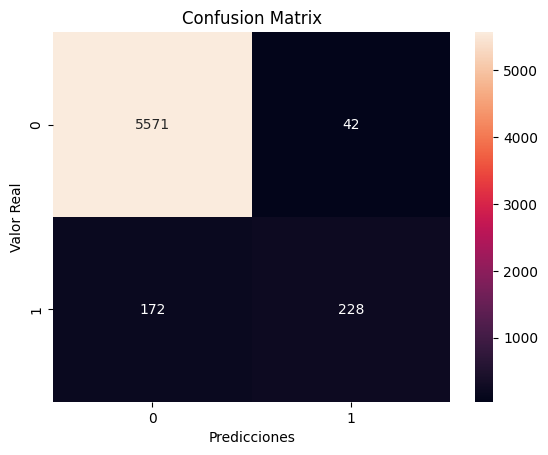

La precision de testeo del modelo con los nuevos estimadores es: 0.9644104440379179

Classification Report:
              precision    recall  f1-score   support

           0     0.9701    0.9925    0.9812      5613
           1     0.8444    0.5700    0.6806       400

    accuracy                         0.9644      6013
   macro avg     0.9072    0.7813    0.8309      6013
weighted avg     0.9617    0.9644    0.9612      6013



In [23]:
#Volvemos a ejecutar el modelo con los estimadores que arrojó la validacion cruzada
# Hacer predicciones con el mejor arbol
y_pred = best_rf.predict(X_test)
class_report = classification_report(y_test, y_pred, digits=4)
# Crear y graficar la matriz de confusión
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='g')
plt.xlabel('Predicciones')
plt.ylabel('Valor Real')
plt.title('Confusion Matrix')
plt.show()

# Calcular y mostrar la precisión
accuracy = accuracy_score(y_test, y_pred)
print(f"La precision de testeo del modelo con los nuevos estimadores es: {accuracy}")
print("\nClassification Report:")
print(class_report)

## Conclusión: 

La Precision con que el modelo evalúa el cero y uno para "arstmade" es:
* 0.97 para No arrestado
* 0.8444 para arrestado
El modelo es mejor clasificando los casos de No Arresto en el 97% de las veces.
Tiene una tasa Recall(sensibilidad) de 99,25% lo que muestra buena capacidad del clasificador de encontrar las muestras positivas.
Tiene una tasa Recall(especificidad) de 57%  lo que muestra que el modelo tiene dificultades para identificar correctamente los casos de arresto. En este indicador es un poco mejor que el modelo de Gradient Boosting (metricas muy parecidas).

# SELECCION DEL MEJOR MODELO

Usamos como  criterio para seleccionar el mejor modelo, aquel que muestra las mejores métricas Accuracy y Sensilibilidad. Seleccionamos las metricas debido a que el dataset se refiere a los procedimientos policiales y es mejor aplicar un modelo que permita asegurar que la mayoría de los casos de arresto sean correctamente identificados como tales. Los costos sociales de un falso positivo son altos: En los tiempos actuales en términos políticos y de vulnerar derechos.
Debido a que los resultados son casis iguales,seleccionamos el Random Forest como el mejor modelo.
Es más sencillo, más rápido, menos propenso a errores de configuración y  permitirá explicar mejor qué variables (como race, age o sector) están influyendo más en las detenciones.